# Code Description 
## Model Evaluation Code 
- This notebook tackles all the code related to data evaluation.

## Part 0 : Code Imports


In [55]:
import torch
import cv2
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from timm import create_model  
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import torchvision.transforms as T
from PIL import Image

## Part 1 : Model Evaluation Code Methods


In [56]:
def build_model(model_name, num_classes=2, pretrained=False):
    model_name = model_name.lower()
    
    if model_name == "convnext_tiny":
        model = models.convnext_tiny(pretrained=pretrained)
        in_features = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(in_features, num_classes)
    
    elif model_name == "vit_base_patch16_224":
        model = models.vit_b_16(pretrained=pretrained)
        in_features = model.heads.head.in_features
        original_head = model.heads.head   
        model.heads.head = nn.Sequential(
            original_head,
            nn.Flatten(),
            nn.BatchNorm1d(in_features),
            nn.Linear(in_features, num_classes),
            nn.Softmax(dim=1)  
        )
    
    elif model_name.startswith("coatnet"):
        model = create_model(model_name, pretrained=pretrained, num_classes=num_classes)
    
    else:
        raise ValueError(f"Unknown model name: {model_name}")
    
    return model

def load_image_paths(data_dir):
    image_paths, labels = [], []
    class_names = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    label_map = {name: idx for idx, name in enumerate(class_names)}
    valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')

    for class_name in class_names:
        class_folder = os.path.join(data_dir, class_name)
        for filename in os.listdir(class_folder):
            if filename.lower().endswith(valid_exts):
                file_path = os.path.join(class_folder, filename).replace("\\", "/")
                try:
                    Image.open(file_path).verify()
                    image_paths.append(file_path)
                    labels.append(label_map[class_name])
                except Exception:
                    print(f"⚠️ Skipping corrupted file: {file_path}")

    return np.array(image_paths), np.array(labels, dtype=np.int64), class_names

class CustomImageDataset(Dataset):
    def __init__(self, image_paths, labels, img_size=(224, 224), augment=False):
        self.image_paths = image_paths
        self.labels = labels
        if augment:
            self.transform = T.Compose([
                T.Resize((256, 256)),
                T.RandomCrop(img_size),
                T.RandomHorizontalFlip(),
                T.RandomVerticalFlip(),
                T.ToTensor(),
                T.Normalize(mean=[0.5]*3, std=[0.5]*3)
            ])
        else:
            self.transform = T.Compose([
                T.Resize(img_size),
                T.ToTensor(),
                T.Normalize(mean=[0.5]*3, std=[0.5]*3)
            ])

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label


def get_dataloader(image_paths, labels, batch_size=32, augment=False, img_size=(224, 224), shuffle=True):
    ds = CustomImageDataset(image_paths, labels, img_size=img_size, augment=augment)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=True, persistent_workers=False)


## Part 2 : Model and Dataset Loading


In [57]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "convnext_tiny"
num_classes = 2

model = build_model(model_name, num_classes=num_classes, pretrained=False).to(device)
state_dict = torch.load("final_model.pth", map_location=device)
model.load_state_dict(state_dict, strict=False)
model.eval()
print("✅ Model loaded for evaluation")

c:\Users\cauba\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\cauba\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Model loaded for evaluation


C:\Users\cauba\AppData\Local\Temp\ipykernel_10436\210916670.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("final_model.pth", map_location=devic

In [58]:
# Change the link to the dataset path of test, this applies for stain normalized testing also

X_test, y_test, class_names = load_image_paths("C:/Users/cauba/OneDrive/Desktop/THESIS_SUB/Original_DS/test")

test_loader = get_dataloader(
    X_test, y_test,
    batch_size=32,
    augment=False,           
    img_size=(224, 224),
    shuffle=False
)

## Part 3 : Model Evaluation


In [59]:
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# Metrics
print("\n📊 Classification Report:")
print(classification_report(all_targets, all_preds, target_names=class_names))


📊 Classification Report:
                 precision    recall  f1-score   support

Margin Negative       1.00      0.89      0.94        35
Margin Positive       0.92      1.00      0.96        48

       accuracy                           0.95        83
      macro avg       0.96      0.94      0.95        83
   weighted avg       0.96      0.95      0.95        83



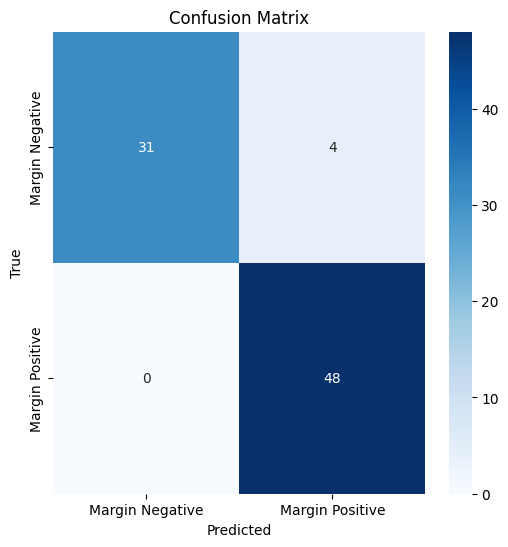

In [60]:
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


## Part 4 : Grad-CAM


In [61]:
import cv2

def gradcam_from_path(img_path, model_name, true_label=None):
    # Load and preprocess image
    img = Image.open(img_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)

    # ---- Prediction ----
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred_class].item()

    pred_name = class_names[pred_class]
    true_name = class_names[true_label] if true_label is not None else "Unknown"

    print(f"✅ Predicted: {pred_name} (Confidence: {confidence:.2f})")
    print(f"🎯 True Label: {true_name}")

    # ---- Grad-CAM ----
        # ---- Select Target Layer Based on Model Name ----
    model_name = model_name.lower()

    if model_name == "convnext_tiny":
        target_layers = [model.features[-1]]  # ConvNeXt last stage
    elif model_name == "vit_base_patch16_224":
        target_layers = [model.encoder.layers[-1].ln_1]  # ViT last encoder norm
    elif model_name.startswith("coatnet"):
        # CoAtNet from timm – check whether stages or blocks exist
        if hasattr(model, "stages"):
            target_layers = [model.stages[-1]]
        elif hasattr(model, "blocks"):
            target_layers = [model.blocks[-1]]
        else:
            raise ValueError("⚠️ Could not find stages/blocks in CoAtNet model.")
    else:
        raise ValueError(f"⚠️ Grad-CAM not configured for model: {model_name}")
    

    cam = GradCAM(model=model, target_layers=target_layers)
    grayscale_cam = cam(input_tensor=input_tensor)[0]

    # Convert original image to numpy
    rgb_img = np.array(img).astype(np.float32) / 255.0

    # Resize CAM to match original image
    grayscale_cam_resized = cv2.resize(grayscale_cam, (rgb_img.shape[1], rgb_img.shape[0]))

    visualization = show_cam_on_image(rgb_img, grayscale_cam_resized, use_rgb=True)

    # ---- Show Results ----
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    ax[0].imshow(rgb_img)
    ax[0].set_title(f"Original\n(True: {true_name})")
    ax[0].axis("off")

    ax[1].imshow(grayscale_cam_resized, cmap="jet")
    ax[1].set_title("Grad-CAM Heatmap")
    ax[1].axis("off")

    ax[2].imshow(visualization)
    ax[2].set_title(f"Pred: {pred_name}\nConf: {confidence:.2f}")
    ax[2].axis("off")

    plt.show()

    # ---- Color Legend ----
    print("""
Grad-CAM Color Interpretation:
🔵 Blue   → little/no importance
🟢 Green  → medium importance
🟡 Yellow → high importance
🔴 Red    → very strong influence (decisive regions)
""")


✅ Predicted: Margin Positive (Confidence: 1.00)
🎯 True Label: Margin Positive


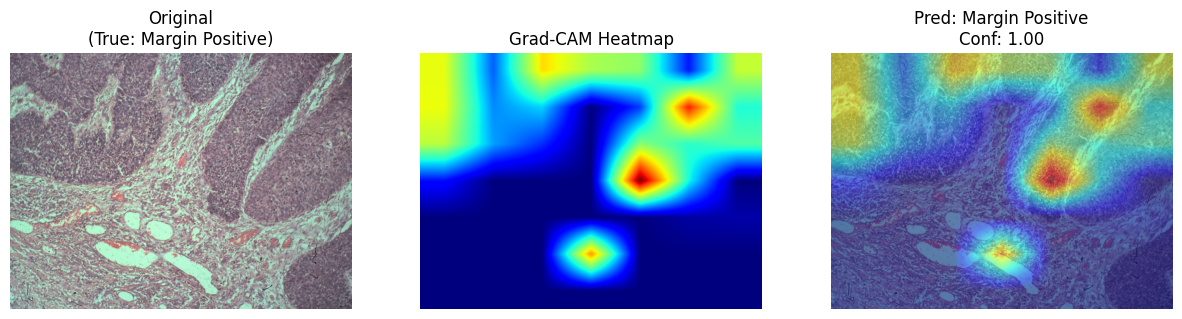


Grad-CAM Color Interpretation:
🔵 Blue   → little/no importance
🟢 Green  → medium importance
🟡 Yellow → high importance
🔴 Red    → very strong influence (decisive regions)



In [62]:
# Change the dataset path to the image you want to test

gradcam_from_path("C:/Users/cauba/OneDrive/Desktop/THESIS_SUB/Original_DS/test/Margin Positive/37TN4.jpg", "convnext_tiny", true_label=1)